In [ ]:
# hi

In [19]:
from tensorflow.keras.datasets import boston_housing
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [2]:
(train_data, train_targets), (test_data, test_targets) = (boston_housing.load_data())

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# normalization:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

In [4]:
def build_model():
  model = keras.Sequential([layers.Dense(64, activation="relu"),
                            layers.Dense(64, activation="relu"),
                            layers.Dense(1)])
  model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
  return model

## Mean Absolute Error (MAE)

For one observation:

$$
AE(y, \hat{y}) = |y - \hat{y}|
$$

For \(N\) observations:

$$
MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

### Parameters

- \(MAE\): mean absolute error
- \(AE\): absolute error for one observation
- \(N\): number of observations
- \(y\): true value for one observation
- \(\hat{y}\): predicted value for one observation
- \(y_i\): true value of observation \(i\)
- \(\hat{y}_i\): predicted value of observation \(i\)
- \(|\cdot|\): absolute value
- \(i\): observation index, from \(1\) to \(N\)

## Mean Squared Error (MSE)

For one observation:

$$
SE(y, \hat{y}) = (y - \hat{y})^2
$$

For \(N\) observations:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

### Parameters

- \(MSE\): mean squared error
- \(SE\): squared error for one observation
- \(N\): number of observations
- \(y\): true value for one observation
- \(\hat{y}\): predicted value for one observation
- \(y_i\): true value of observation \(i\)
- \(\hat{y}_i\): predicted value of observation \(i\)
- \(i\): observation index, from \(1\) to \(N\)

In [5]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []


for i in range(k):
  print(f"Processing fold #{i}")
  val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
  partial_train_data = np.concatenate([train_data[:i * num_val_samples],
                                      train_data[(i + 1) * num_val_samples:]],
                                      axis=0)
  partial_train_targets = np.concatenate([train_targets[:i * num_val_samples],
                                          train_targets[(i + 1) * num_val_samples:]],
                                          axis=0)
  model = build_model()

  model.fit(partial_train_data,
            partial_train_targets,
            epochs=num_epochs, batch_size=16, verbose=1)

  val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=1)

  all_scores.append(val_mae)

Processing fold #0
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 522.5779 - mae: 20.9697
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 388.4047 - mae: 17.5943  
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254.6021 - mae: 13.6860 
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 142.4248 - mae: 9.7820  
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 77.2836 - mae: 6.9784 
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47.6787 - mae: 5.2585 
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.6632 - mae: 4.2808 
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.4629 - mae: 3.6982 
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.7046 - mae: 3.3457 
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.4501 - mae: 3.1615
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.1713 - mae: 2.9737
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.1677 - m

In [6]:
all_scores
# mae in all val folds

[1.9919612407684326, 2.3479092121124268, 2.5857033729553223, 2.373981475830078]

In [7]:
np.mean(all_scores)

np.float64(2.324888825416565)

In [8]:
num_epochs = 500
all_mae_histories = []

for i in range(k):
  print(f"Processing fold #{i}")
  val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
  partial_train_data = np.concatenate([train_data[:i * num_val_samples],
                                       train_data[(i + 1) * num_val_samples:]],
                                       axis=0)
  partial_train_targets = np.concatenate([train_targets[:i * num_val_samples],
                                          train_targets[(i + 1) * num_val_samples:]],
                                          axis=0)
  model = build_model()

  history = model.fit(partial_train_data,
                      partial_train_targets,
                      validation_data=(val_data, val_targets),
                      epochs=num_epochs, batch_size=16, verbose=0)

  mae_history = history.history["val_mae"]
  all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [21]:
len(all_mae_histories)

4

In [23]:
len(all_mae_histories[0])

500

In [ ]:
# Mean average error across the 4 folds over 500 epochs

In [9]:
average_mae_history = [
np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

In [14]:
len(average_mae_history)

500

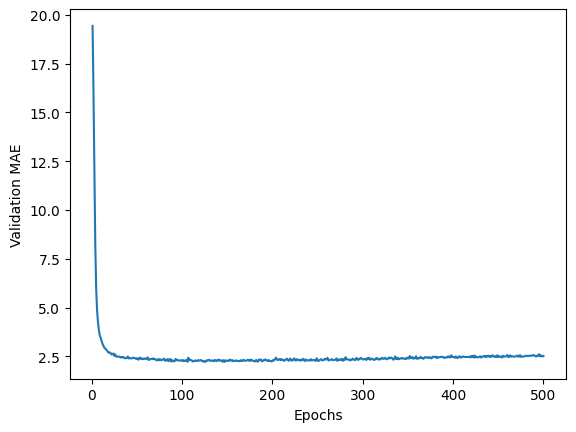

In [20]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()


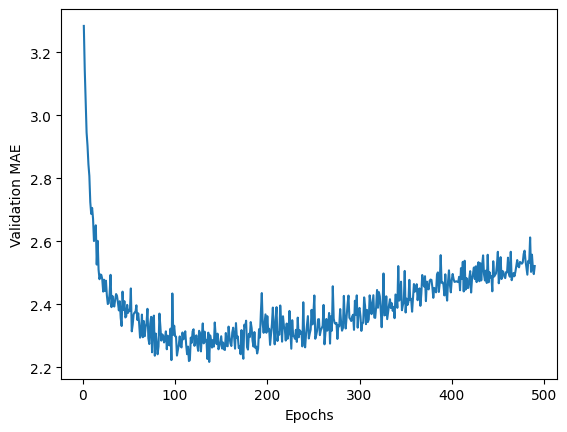

In [26]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()